In [8]:
import numpy as np
import scipy
from Scripts.Optimization.optimization import Optimizer
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.material_properties import Materials


In [14]:
opt = Optimizer()
opt.independent_properties_calc()
opt.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
opt.design_variables_initial_guess = {
    "arm_diameter": 50,
    "arm_thickness": 2.5,
    "strut_diameter": 40.0,
    "strut_thickness": 0.254,
    "strut_distance": 475,
    "hub_radius": 300,
    "hub_flange_thickness": 3,
    "hub_web_thickness": 2
}

res = opt.run_opt()

x = np.array(res.x)
x_expanded = list(opt.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt.test_results(x)


dv_keys = list(opt.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"objective: {res.fun}")


print("OPT_OUTPUT")
opt.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

C:\Users\Nathan\Desktop\UAV\Scripts\Finite_Elements\Beam_FEA_System\beam_system.py:394: LinAlgWarning: Ill-conditioned matrix (rcond=1.45751e-19): result may not be accurate.
  self.du = scipy.linalg.solve(self.kuu, self.ru - (self.kup @ self.dp))
C:\Users\Nathan\Desktop\UAV\Scripts\Finite_Elements\Beam_FEA_System\beam_system.py:542: LinAlgWarning: Ill-conditioned matrix (rcond=1.81083e-19): result may not be accurate.
  du = scipy.linalg.solve(self.kduu, ru - (self.kdup @ self.dp))
C:\Users\Nathan\Desktop\UAV\Scripts\Finite_Elements\Beam_FEA_System\beam_system.py:542: LinAlgWarning: Ill-conditioned matrix (rcond=2.13545e-19): result may not be accurate.
  du = scipy.linalg.solve(self.kduu, ru - (self.kdup @ self.dp))
C:\Users\Nathan\Desktop\UAV\Scripts\Finite_Elements\Beam_FEA_System\beam_system.py:542: LinAlgWarning: Ill-conditioned matrix (rcond=2.47724e-19): result may not be accurate.
  du = scipy.linalg.solve(self.kduu, ru - (self.kdup @ self.dp))
C:\Users\Nathan\Desktop\UAV\Scri

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3720082979415648
   strut_diameter: 9.0
   strut_thickness: 0.2540000000000002
   strut_distance: 197.50083582931305
   hub_radius: 197.5
   hub_flange_thickness: 0.7000000000000001
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000005176748
   stress: 0.8325252627275124
   displacement amplitude: 0.5418719154094512
   energy: 0.8692144800395152
   damage: 0.0
objective: 0.6716397946182086
OPT_OUTPUT
Initial guess opt actual:
[ 50.           0.3720083    9.           0.254      197.50083583
 197.5          0.7          0.7       ]


In [10]:
initial_design_vars = opt.design_variables_initial_guess
active_constraints = opt.active_constraints
constraints_res, labels = opt.constraint_calculations(initial_design_vars, active_constraints)

print("===== Initial Guess =====")
print("constraints")
for i in range(len(constraints_res)):
    print(f"   {labels[i]}: {constraints_res[i]}")

===== Initial Guess =====
constraints
   deflection: 0.13247649457152025
   stress: 0.1227874567886745
   displacement amplitude: 0.8287849109539941


In [11]:
import os
import pandas as pd

table_path = "Tables/Sensitivity_Testing_Ver_2.csv"

des_var_num = len(x)
test_num = 2 ** des_var_num
x2 = np.zeros([test_num,des_var_num])

eps = 0.001

for i in range(test_num):
    for j in range(des_var_num):
        sign = 2 * ((i >> j) & 1) - 1
        print(sign,end=',')
        x2[i, j] = x[j] * (1 + eps * sign)
    print("")


for i in range(des_var_num):
    case_title = "Case " + str(i)
    print(x2)
    cons_res_opt, cons_labels_opt = opt.test_results(x2[i])
    mass = opt.mass(opt.reform_dvs(x2[i]))

    data = {}
    data.update(opt.reform_dvs(x2[i]))
    opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
    data.update(opt_dictionary)
    data.update({"mass": mass * 1000})

    print(data)

    # Ensure directory exists
    os.makedirs(os.path.dirname(table_path), exist_ok=True)

    new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

    if os.path.exists(table_path):
        try:
            df_existing = pd.read_csv(table_path, index_col=0)
        except Exception:
            df_existing = pd.DataFrame()

        if df_existing.empty:
            df = new_col_df
        else:
            for idx in new_col_df.index:
                if idx not in df_existing.index:
                    df_existing.loc[idx] = pd.NA
            df_existing[case_title] = new_col_df[case_title]
            df = df_existing
    else:
        df = new_col_df

    df.to_csv(table_path, index=True)


-1,-1,
1,-1,
-1,1,
1,1,
[[  0.37167775 197.3025    ]
 [  0.37242185 197.3025    ]
 [  0.37167775 197.6975    ]
 [  0.37242185 197.6975    ]]
{'arm_diameter': 50, 'arm_thickness': np.float64(0.37167775095033173), 'strut_diameter': 9, 'strut_thickness': 0.254, 'strut_distance': np.float64(197.30250000000012), 'hub_radius': 197.5, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.0018700038317316), 'stress': np.float64(0.8334268330615983), 'displacement amplitude': np.float64(0.540726118343096), 'energy': np.float64(0.8692050629354731), 'damage': np.float64(0.0), 'mass': np.float64(0.9153134828308664)}
[[  0.37167775 197.3025    ]
 [  0.37242185 197.3025    ]
 [  0.37167775 197.6975    ]
 [  0.37242185 197.6975    ]]
{'arm_diameter': 50, 'arm_thickness': np.float64(0.37242185055183386), 'strut_diameter': 9, 'strut_thickness': 0.254, 'strut_distance': np.float64(197.30250000000012), 'hub_radius': 197.5, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 

In [12]:
import os
import pandas as pd
table_path = "Tables/Sensitivity_Testing_Ver_2.csv"
case_title = "Optimal Point"

mass = opt.mass(opt.reform_dvs(x))

data = {}
data.update(opt.reform_dvs(x))
opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
data.update(opt_dictionary)
data.update({"mass":mass * 1000})

print(data)

# Ensure directory exists
os.makedirs(os.path.dirname(table_path), exist_ok=True)

new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

if os.path.exists(table_path):
    try:
        df_existing = pd.read_csv(table_path, index_col=0)
    except Exception:
        df_existing = pd.DataFrame()

    if df_existing.empty:
        df = new_col_df
    else:
        for idx in new_col_df.index:
            if idx not in df_existing.index:
                df_existing.loc[idx] = pd.NA
        df_existing[case_title] = new_col_df[case_title]
        df = df_existing
else:
    df = new_col_df

df.to_csv(table_path, index=True) 


{'arm_diameter': 50, 'arm_thickness': np.float64(0.3720498007510828), 'strut_diameter': 9, 'strut_thickness': 0.254, 'strut_distance': np.float64(197.5000000000001), 'hub_radius': 197.5, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.0001620653546117), 'stress': np.float64(0.831798870242044), 'displacement amplitude': np.float64(0.5404149310527163), 'energy': np.float64(0.8692257953068998), 'damage': np.float64(0.0), 'mass': np.float64(0.9158453289363236)}


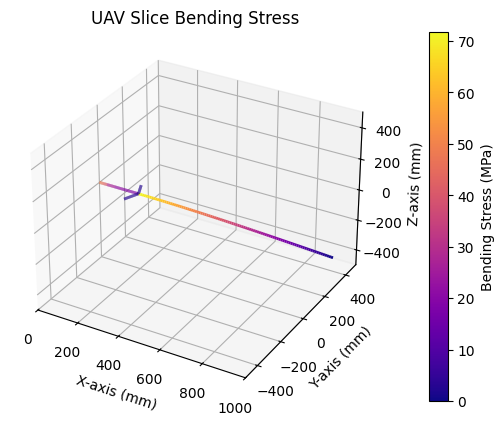

In [9]:
from Scripts.visualization import drone_geometry_stress

drone_geometry_stress(opt.fea, 1, 100)

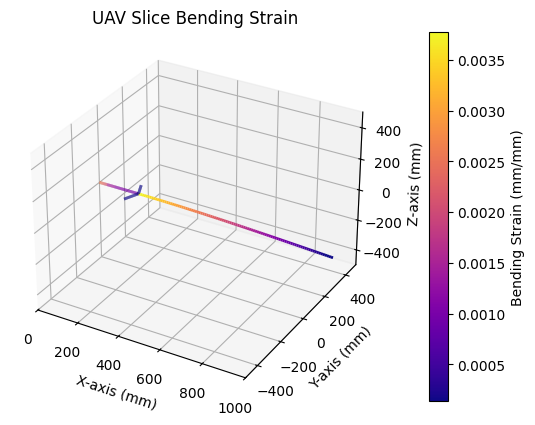

In [10]:
from Scripts.visualization import drone_geometry_strain

drone_geometry_strain(opt.fea, 1, 100)

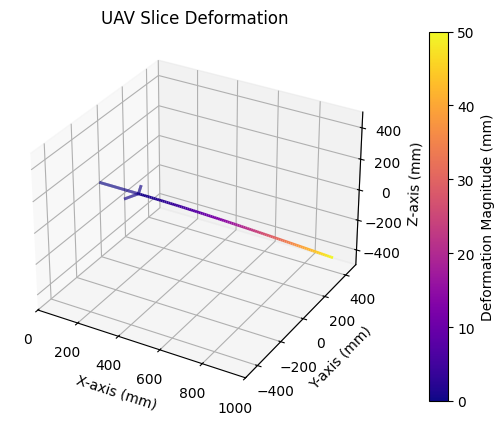

In [11]:
from Scripts.visualization import drone_geometry_deformation

drone_geometry_deformation(opt.fea, 1, 100)

In [12]:
import Scripts.unit_conversions as uc
opt.fea.beam_system.solve_natural_frequencies()
print(f"First Nf: {opt.fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {opt.fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")

First Nf: 26.873275669615868 Hz
Second Nf: 64.63158112262225 Hz


In [13]:
# plot the space
'''
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 50, design_variables, (400, 600), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''
# plot the space
'''
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 50, design_variables, (0.2, 0.5), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''
# zoomed out
'''
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 75, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''

'''
# TEST
from Scripts.visualization import design_space_test_cons
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_test_cons(opt, "strut_distance", "strut_thickness", 25, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''

'\n# TEST\nfrom Scripts.visualization import design_space_test_cons\nimport matplotlib.pyplot as plt\n\ndesign_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}\n\ndesign_space_test_cons(opt, "strut_distance", "strut_thickness", 25, design_variables, None,None, {\n    "deflection": True,\n    "stress": True,\n    "frequency": True,\n    "natural frequency": False,\n    "energy": False,\n    "damage": False,\n})\nax = plt.gca()\nplt.scatter(x_expanded[4], x_expanded[3], c=\'white\', edgecolor=\'k\', zorder=100) # check this\n\nax.set_axisbelow(False)\nplt.title(\'Constraints\')\nplt.xlabel(\'strut distance (mm)\')\nplt.ylabel(\'strut thickness (mm)\')\nplt.show()\n'

In [14]:
### Constraint Tester ###

design_variables = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": x_expanded[3],
    "strut_distance": x_expanded[4],
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}
constraints_res, labels = opt.constraint_calculations(design_variables, active_constraints, True)
for i in range(len(constraints_res)):
    print(f"{labels[i]}: {constraints_res[i]}")

deflection: 1.0000001130298604
stress: 0.8324554212804666
displacement amplitude: 0.541983335127786


In [15]:
# plot the space
'''
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 75, design_variables, None, None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''

'\nfrom Scripts.visualization import design_space_mass\nimport matplotlib.pyplot as plt\n\ndesign_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}\n\ndesign_space_mass(opt, "arm_thickness", "strut_thickness", 75, design_variables, None, None, {\n    "deflection": True,\n    "stress": True,\n    "frequency": True,\n    "natural frequency": False,\n    "energy": False,\n    "damage": False,\n})\nax = plt.gca()\nplt.scatter(x_expanded[1], x_expanded[3], c=\'white\', edgecolor=\'k\', zorder=100) # check this\n\nax.set_axisbelow(False)\nplt.title(\'Viable Design Space\')\nplt.xlabel(\'arm thickness (mm)\')\nplt.ylabel(\'strut thickness (mm)\')\nplt.show()\n'

In [16]:
'''
# plot the space
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 50, design_variables,(197.5,300),(0.254,0.5),{
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''

'\n# plot the space\nfrom Scripts.visualization import design_space_freq\nimport matplotlib.pyplot as plt\n\ndesign_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}\n\ndesign_space_freq(opt, "strut_distance", "strut_thickness", 50, design_variables,(197.5,300),(0.254,0.5),{\n    "deflection": False,\n    "stress": False,\n    "frequency": True,\n    "natural frequency": False,\n    "energy": False,\n    "damage": False,\n})\nplt.scatter(x_expanded[4], x_expanded[3], c=\'r\')\nplt.title(\'Constraints\')\nplt.xlabel(\'strut distance (mm)\')\nplt.ylabel(\'strut thickness (mm)\')\nplt.show()\n'

In [17]:
'''
# zoomed out
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 75, design_variables,None,None, {
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()
'''

'\n# zoomed out\nfrom Scripts.visualization import design_space_freq\nimport matplotlib.pyplot as plt\n\ndesign_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}\n\ndesign_space_freq(opt, "strut_distance", "strut_thickness", 75, design_variables,None,None, {\n    "deflection": False,\n    "stress": False,\n    "frequency": True,\n    "natural frequency": False,\n    "energy": False,\n    "damage": False,\n})\nplt.scatter(x_expanded[4], x_expanded[3], c=\'r\')\nplt.title(\'Constraints\')\nplt.xlabel(\'strut distance (mm)\')\nplt.ylabel(\'strut thickness (mm)\')\nplt.show()\n'

Initial guess 1 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 25,
    "strut_diameter": 50.0,
    "strut_thickness": 25,
    "strut_distance": 510,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31612437848973063
   strut_diameter: 50.0
   strut_thickness: 0.3602027837054039
   strut_distance: 509.98696996881597
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999970214
   stress: 0.955560709497491
   frequency: 0.26171190065852373
   energy: 0.326065371252493
   damage: 0.0
mass w/ payload: 0.8265042304244963 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16124378e-01 3.60202784e-01 5.09986970e+02]

Initial guess 2 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 1,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}


===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3022755041161241
   strut_diameter: 50.0
   strut_thickness: 0.3608985852993385
   strut_distance: 556.6928996805128
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999539
   stress: 0.9780731466461088
   frequency: 0.2914667465901592
   energy: 0.3260612237046038
   damage: 0.0
mass w/ payload: 0.8250114520506969 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275504e-01 3.60898585e-01 5.56692900e+02]

Inital Guess 3 tol=1e-18

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30227574532156787
   strut_diameter: 50.0
   strut_thickness: 0.3608980022929013
   strut_distance: 556.6928997650245
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.999999999999994
   stress: 0.9780730549779
   frequency: 0.29146623894235507
   energy: 0.32606122370460633
   damage: 0.0
mass w/ payload: 0.8250114520506582 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275745e-01 3.60898002e-01 5.56692900e+02]

Initial Guess 4 tol=1e-18

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31654251873360006
   strut_diameter: 50.0
   strut_thickness: 0.48657929350939877
   strut_distance: 412.17184660354866
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000000000013
   stress: 1.0000000000000078
   frequency: 1.0000000000001152
   energy: 0.3261353943704316
   damage: 0.0
mass w/ payload: 0.8461615400019418 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16542519e-01 4.86579294e-01 4.12171847e+02]

In [18]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc
uav_geo = opt.drone_geometry
uav_fea = fea.DroneFEA(uav_geo)
uav_fea.create_drone_nodes()
uav_fea.create_drone_beams()
# uav_fea.boundary_conditions()
uav_fea.solve_fea()
uav_fea.beam_system.solve_natural_frequencies()
np.set_printoptions(precision=3,suppress=True)
print(f"First Nf: {uav_fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {uav_fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")
print(f"Third Nf: {uav_fea.beam_system.natural_frequencies[2] * uc.rad_per_s_to_Hz} Hz")
print(f"Fourth Nf: {uav_fea.beam_system.natural_frequencies[3] * uc.rad_per_s_to_Hz} Hz")
print(f"Nf: {uav_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz} Hz")

First Nf: 0.0 Hz
Second Nf: 0.0 Hz
Third Nf: 0.0 Hz
Fourth Nf: 0.0 Hz
Nf: [     0.         0.         0.         0.         0.003      0.026
     26.874     26.874     26.889     26.889     26.905     27.712
     27.712     27.872     27.872     27.906     28.896     28.896
     31.506     58.929     60.37      60.37      62.032     62.032
     62.407     62.407     62.986     76.358     76.707     76.707
    110.33     115.545    115.545    120.557    120.557    122.241
    122.241    122.566    129.565    129.565    129.632    129.632
    129.71     132.456    132.456    133.533    133.533    134.235
    134.235    134.381    136.696    139.721    147.353    147.353
    166.292    166.292    167.033    167.033    167.676    173.088
    173.399    173.399    175.075    175.398    175.398    178.924
    178.924    198.572    198.572    204.988    231.838    231.839
    231.839    231.84     231.84     231.847    231.851    231.851
    308.541    308.541    309.277    309.277    309.495

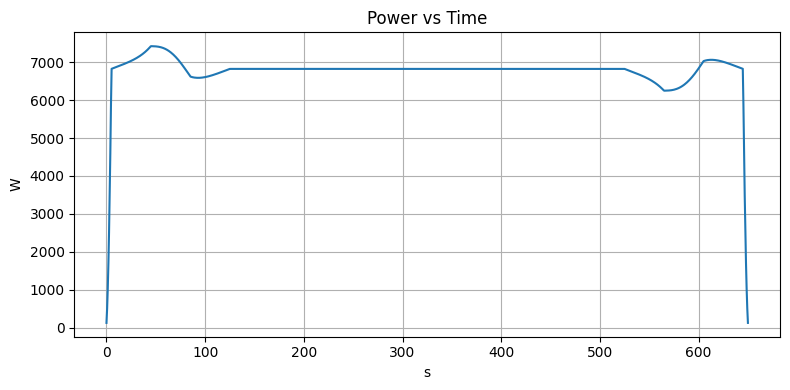

In [19]:
import matplotlib.pyplot as plt
import Scripts.unit_conversions as uc

drone_power = opt.drone_power_module
m1 = opt.mission_profile

power_list = drone_power.timesteps.copy()
thrust_list = drone_power.timesteps.copy()
osc_list = drone_power.timesteps.copy()
time_list = drone_power.timesteps.copy()
drone_mass = opt.drone_mass
surface_area = opt.drone_geometry.projected_surface_area
for i, t in enumerate(time_list):
    power_list[i] = drone_power.power_at_time(t)
    thrust_list[i] = opt.total_force_y(t, drone_mass, surface_area)
    osc_list[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)


print(opt.mission_profile)
# Power vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Power vs Time")
plt.plot(time_list, power_list / 1000)
plt.grid()
plt.ylabel("W")
plt.xlabel("s")
plt.tight_layout()
plt.show()

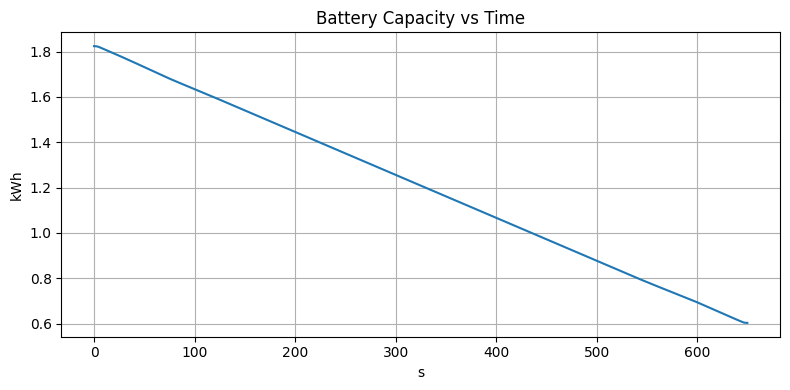

In [20]:

# Battery Capacity vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Battery Capacity vs Time")
plt.plot(drone_power.timesteps, drone_power.energy_remaining * uc.s_to_hrs * uc.mW_to_kW)
plt.grid()
plt.ylabel("kWh")
plt.xlabel("s")
plt.tight_layout()
plt.show()

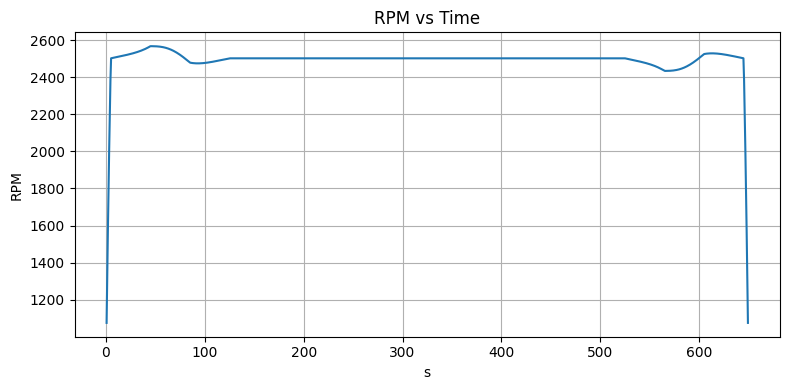

In [21]:

# Throttle vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("RPM vs Time")
plt.plot(drone_power.timesteps[1:-1], drone_power.rpm[1:-1])
plt.grid()
plt.ylabel("RPM")
plt.xlabel("s")
plt.tight_layout()
plt.show()


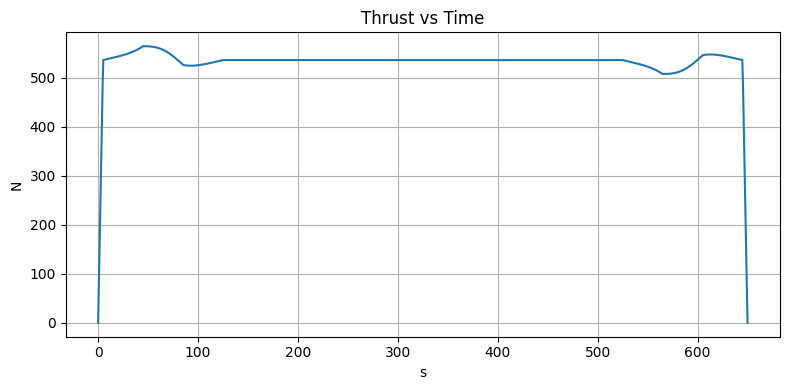

In [22]:
plt.figure(figsize=(8, 4))
plt.title("Thrust vs Time")
plt.plot(time_list, thrust_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

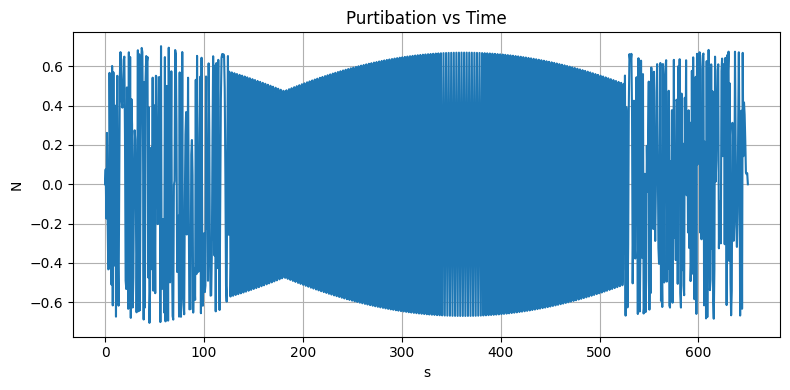

In [23]:
plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list, osc_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

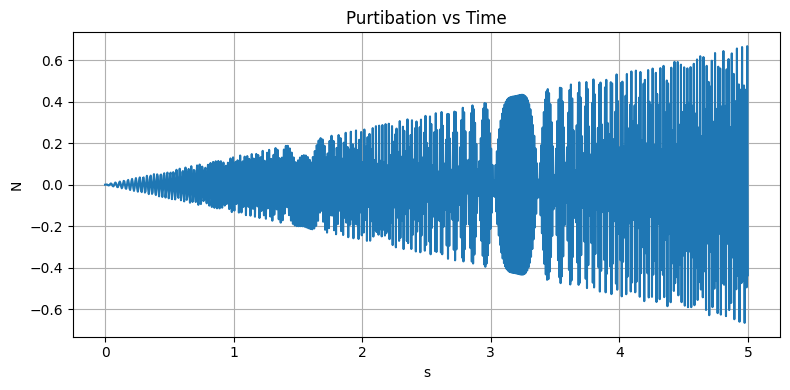

In [24]:

time_list_2 = np.linspace(0, 5, 1000)
osc_list_2 = np.zeros(len(time_list_2))
for i, t in enumerate(time_list_2):
    osc_list_2[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)

plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list_2, osc_list_2)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

In [ ]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}
print(design_variables)
design_space_obj(opt, "arm_diameter", "arm_thickness", 100, design_variables, (9, 50), (0.254, 3.175), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[0], x_expanded[1], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm diameter (mm)')
plt.ylabel('arm thickness (mm)')
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': 0.37200814947838434, 'strut_diameter': np.float64(50.0), 'strut_thickness': np.float64(3.175), 'strut_distance': 197.57920063889856, 'hub_radius': 197.5, 'hub_flange_thickness': 0.7000000000000002, 'hub_web_thickness': 0.7}


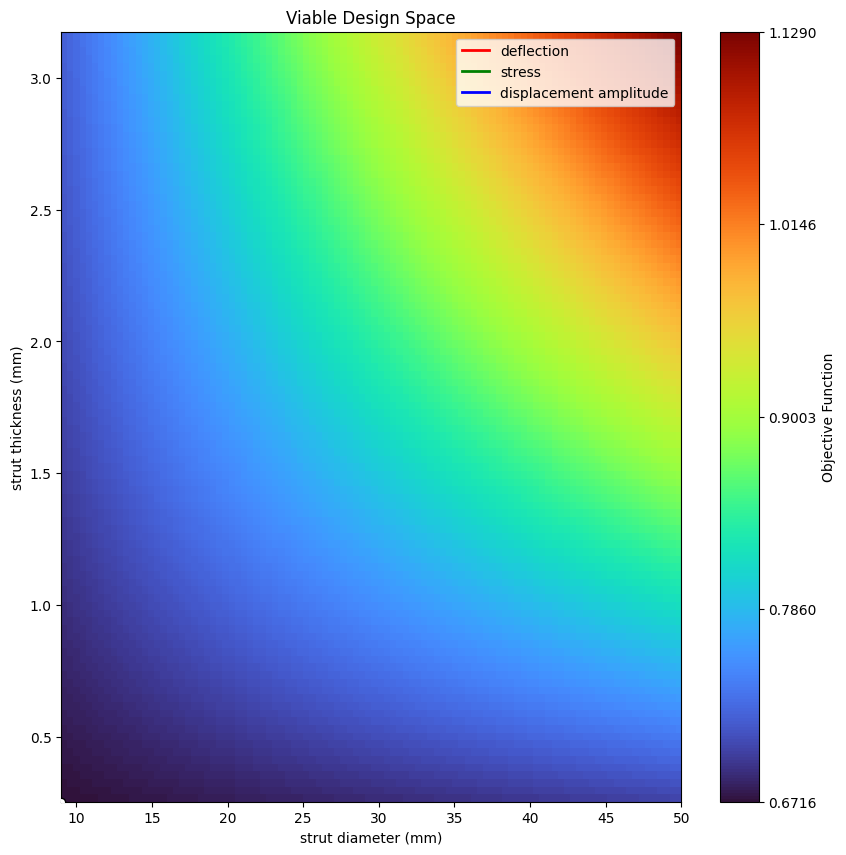

In [26]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_obj(opt, "strut_diameter", "strut_thickness", 100, design_variables, (9, 50), (0.254, 3.175), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[2], x_expanded[3], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut diameter (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

In [27]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_obj(opt, "strut_distance", "hub_radius", 100, design_variables, (197.5, 1127.3), (197.5, 1127.3), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[5], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut center distance (mm)')
plt.ylabel('hub radius (mm)')
plt.show()

C:\Desktop\UAV_Mission\Scripts\Finite_Elements\FEA_3D.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  x = a*e/l
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\FEA_3D.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  phi_y = 12 * e * i_z * k_y / (a * g * (l ** 2))
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\FEA_3D.py:8: RuntimeWarning: invalid value encountered in scalar multiply
  y_1 = 12 * e * i_z / ((1 + phi_y) * l ** 3) # I1 # Ix
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\FEA_3D.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  y_2 = 6 * e * i_z / ((1 + phi_y) * l ** 2)
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\FEA_3D.py:10: RuntimeWarning: invalid value encountered in scalar multiply
  y_3 = (4 + phi_y) * e * i_z / ((1 + phi_y) * l)
C:\Desktop\UAV_Mission\Scripts\Finite_Elements\FEA_3D.py:11: RuntimeWarning: invalid value encountered in scalar multiply
  y_4 = (2 - phi_y) * e * i_z / ((1 + phi_y) * l)
C:\Desktop\

ValueError: array must not contain infs or NaNs

{'arm_diameter': 50.0, 'arm_thickness': 0.37200814947838434, 'strut_diameter': 9.0, 'strut_thickness': 0.254, 'strut_distance': 197.57920063889856, 'hub_radius': 197.5, 'hub_flange_thickness': 0.7000000000000002, 'hub_web_thickness': 0.7}
{'arm_diameter': np.float64(50.0), 'arm_thickness': np.float64(3.175), 'strut_diameter': 9.0, 'strut_thickness': 0.254, 'strut_distance': 197.57920063889856, 'hub_radius': 197.5, 'hub_flange_thickness': 0.7000000000000002, 'hub_web_thickness': 0.7}


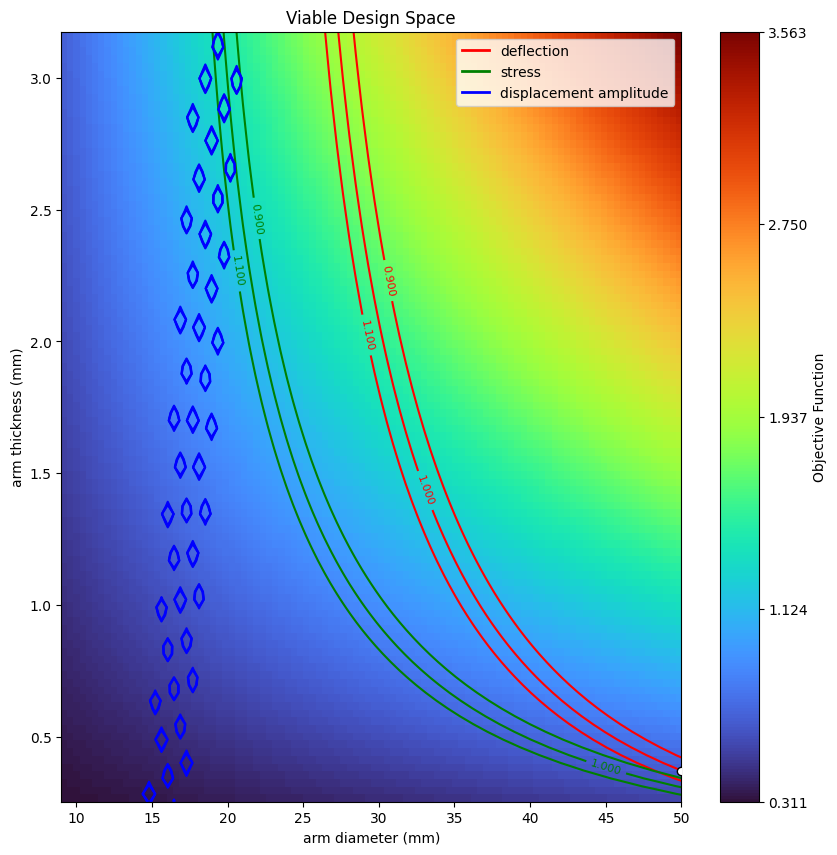

In [25]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}
print(design_variables)
design_space_obj(opt, "arm_diameter", "arm_thickness", 100, design_variables, (45, 50), (0.2, 0.7), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[0], x_expanded[1], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm diameter (mm)')
plt.ylabel('arm thickness (mm)')
plt.show()


In [114]:
## Transient Results ##

print("Transient")
fea_seg = opt.fea.beam_system
for i in range(len(fea_seg.beams)):
    print(np.max(np.array([fea_seg.beams[i].bending_stresses_0_ts, fea_seg.beams[i].bending_stresses_1_ts])))

# 133 MPa
# Strength
print(f"Displacements: ")
for z in fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1]:
    print(f"{z}, ", end='')

print(f"\nMax Deflection: {np.max(fea_seg.beams[fea_seg.select_element("outer_beam")].z_displacements_global_ts[:,1])}")

Transient
61.34911111304048
35.971926899155804
28.769411731577833
25.394016888397758
23.069976329079648
129.5976469005132
133.5505390451796
58.1253969103936
58.12539691039308
Displacements: 
0.0, 7.95198897982967, 15.719759071784013, 23.776485920402116, 31.71446932041046, 39.27071987226135, 48.05414102701513, 55.28924186058335, 61.56683798408395, 61.52804547669251, 60.94172077851061, 60.47783509776138, 61.43882733552373, 61.36503576396651, 60.73115349833751, 61.74854139740106, 60.84031221434113, 61.38621556845473, 61.84902912044872, 60.99702257156896, 60.832429865450834, 60.99777051945384, 61.04903165349139, 60.92928961166109, 61.51486551073131, 62.20087867981616, 61.14470457471524, 61.97394237578949, 62.46290771573594, 62.49441737879345, 62.25209602882383, 61.509837196519456, 62.08975623163047, 62.37370905485299, 61.73683543717816, 62.99759704249252, 63.0985006419326, 62.55524572425142, 63.38658419456533, 62.89041307019022, 63.658463925315566, 63.05856897175808, 63.656494591592825, 63

In [ ]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_obj(opt, "strut_diameter", "strut_thickness", 100, design_variables, (0.7, 12.7), (0.7, 12.7), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[6], x_expanded[7], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('hub flange thickness (mm)')
plt.ylabel('hub web thickness (mm)')
plt.show()

In [35]:

design_variables = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": x_expanded[3],
    "strut_distance": x_expanded[4],
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
print(design_variables)
active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}
constraints_res, labels = opt.constraint_calculations(design_variables, active_constraints, True)
for i in range(len(constraints_res)):
    print(f"{labels[i]}: {constraints_res[i]}")

print(f"Obj: {opt.objective(design_variables)}")


{'arm_diameter': np.float64(50.0), 'arm_thickness': np.float64(0.37200814947838434), 'strut_diameter': np.float64(9.0), 'strut_thickness': np.float64(0.254), 'strut_distance': np.float64(197.57920063889856), 'hub_radius': np.float64(197.5), 'hub_flange_thickness': np.float64(0.7000000000000002), 'hub_web_thickness': np.float64(0.7)}
deflection: 1.0000001130298604
stress: 0.8324554212804666
displacement amplitude: 0.541983335127786
Obj: 0.6716424469127906


In [34]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc

## FEA Model Segment ##
fea_model_seg = opt.fea.beam_system

uav_fea_model_full = fea.DroneFEA(opt.drone_geometry)
uav_fea_model_full.create_drone_nodes()
uav_fea_model_full.create_drone_beams()
uav_fea_model_full.boundary_conditions()
uav_fea_model_full.solve_fea()

fea_model_full = uav_fea_model_full.beam_system


Full 50mm disp:
First 10 Natural Frequencies: [12.986 15.951 16.795 16.795 18.555 18.555 20.034 20.034 20.589 22.671
 23.426 23.426 25.233 25.233 26.991 26.991 27.699 44.013 44.05  44.05
 44.15  44.15  44.27  44.27  44.327 73.107 73.374 73.374 74.007 74.007] Hz
Segment 50mm disp:
First 10 Natural Frequencies: [   20.884    43.694    45.79     45.811    45.811    53.068    84.719
   119.693   148.765   166.373   315.769   900.972  1174.162  1309.738
  1309.842  2284.61   3817.981  5380.231  8001.889  9363.193 10743.614
 13228.599 15544.941 16130.848 19193.242 20259.926 20536.407 20547.524
 22815.119 23089.013] Hz
Prop Frequency Range: 81.20321259220303-86.22452532673637 Hz


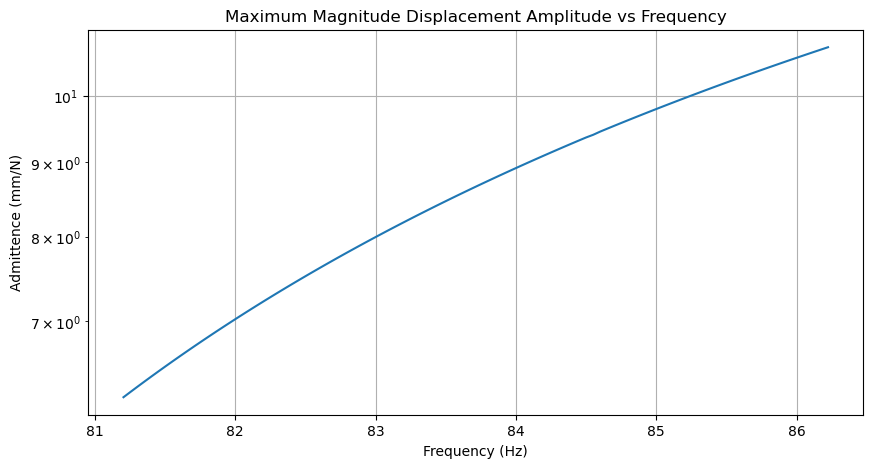

In [36]:
import matplotlib.pyplot as plt

## Freuency Analysis ##
fea_model_seg.solve_natural_frequencies()
fea_model_full.solve_natural_frequencies()

nat_fre_hz = fea_model_seg.natural_frequencies * uc.rad_per_s_to_Hz
full_nat_fre_hz = fea_model_full.natural_frequencies * uc.rad_per_s_to_Hz

print(f"Full 50mm disp:")
print(f"First 10 Natural Frequencies: {full_nat_fre_hz[:30]} Hz")

print("Segment 50mm disp:")
print(f"First 10 Natural Frequencies: {nat_fre_hz[:30]} Hz")


# Max Frequency #

drone_power = opt.drone_power_module
drone_power.freq_trans_calc()
max_freq = np.max(drone_power.frequency)
min_freq = np.min(drone_power.frequency[15:-15])
print(f"Prop Frequency Range: {min_freq * uc.rad_per_s_to_Hz}-{max_freq * uc.rad_per_s_to_Hz} Hz")

## Freuency Plotting ##
n_samples = 100
frequency_sample = np.linspace(min_freq, max_freq, n_samples)



max_amps = []
force = opt.parameters["gravity"] * (opt.parameters["payload"] / opt.parameters["blade_num"])
for freq in frequency_sample:
    test_freq_fea = fea_model_full
    test_freq_fea.init_dynamic_forces(freq)
    for i in range(7):
        node = f"outer_node_{i}"
        test_freq_fea.add_dynamic_harmonic_force(np.array([0, 0, 1, 0, 0, 0]), node)
    test_freq_fea.solve_dynamic_harmonic(0,0)
    max_amps.append(max(test_freq_fea.mag_displacements_amplitude))

plt.figure(figsize=(10, 5))
plt.plot(frequency_sample * uc.rad_per_s_to_Hz, max_amps)
plt.title("Maximum Magnitude Displacement Amplitude vs Frequency")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Admittence (mm/N)") #### Remeber ths ##
plt.grid(True)
plt.yscale('log')
plt.show()


In [26]:
## Energy Analysis ##


drone_power = opt.drone_power_module

print(f"Total Energy Capacity: {drone_power.milliwatt_hour_capacity*10**-6} kWh")
print(f"Final Energy Remaining: {drone_power.energy_remaining[-1] * uc.s_to_hrs*10**-6} kWh")
print(f"% Energy Remaining: {drone_power.energy_remaining[-1] * uc.s_to_hrs*10**-6} %")
print(f"Mission Duration: {opt.mission_profile.duration} s")
print(f"Min Throttle: {np.min(drone_power.percent_throttle) * 100:.2f} %")
print(f"Average Throttle: {np.mean(drone_power.percent_throttle) * 100:.2f} %")
print(f"Peak Throttle: {np.max(drone_power.percent_throttle) * 100:.2f} %")


print(f"Min RPM: {np.min(drone_power.rpm) * 100:.2f} RPM")
print(f"Average RPM: {np.mean(drone_power.rpm) * 100:.2f} RPM")
print(f"Peak RPM: {np.max(drone_power.rpm) * 100:.2f} RPM")
print(f"Max RPM: 3068")



Total Energy Capacity: 1.8239999999999998 kWh
Final Energy Remaining: 0.5226889469200263 kWh
% Energy Remaining: 0.5226889469200263 %
Mission Duration: 640 s
Min Throttle: 0.79 %
Average Throttle: 45.00 %
Peak Throttle: 50.96 %
Min RPM: 80573.00 RPM
Average RPM: 253856.67 RPM
Peak RPM: 264226.16 RPM
Max RPM: 3068


I will summarize the analysis of the `drone_power` object by calculating and displaying its core attributes, including energy consumption and throttle performance over the mission duration.



In [85]:
# Displacement / Stress

fea_seg = opt.fea.beam_system

max_disp = print(f"max disp: {np.max(fea_seg.mag_displacements)}")
max_disp = print(f"max disp: {fea_seg.beams[fea_seg.select_element("outer_beam")].bending_stresses_0} Mpa")

max disp: 50.000000000000384
6
max disp: 75.58657942887487 Mpa


In [26]:
## MASS ##
dv = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": x_expanded[3],
    "strut_distance": x_expanded[4],
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
print(f"Initial Guess")
print(f"Frame mass: {opt.mass(opt.design_variables_initial_guess) * 1000} kg")
print(f"Frame mass moment of inertia: {opt.moment(opt.design_variables_initial_guess) * 10**-3}  kg*m^2")
print(f"Objective: {opt.objective(opt.design_variables_initial_guess)}")
print("Optimized")

print(f"Frame mass: {opt.mass(dv) * 1000} kg")
print(f"Frame mass moment of inertia: {opt.moment(dv) * 10**-3} kg*m^2")
print(f"Objective: {opt.objective(dv)}")

mass_contr = opt.mass(dv) * opt.constraints_constants["weight_mass"] / opt.constraints_constants["scaling_mass"]
mass_moment_contr = opt.moment(dv) * opt.constraints_constants["weight_mass_moment"] / opt.constraints_constants["scaling_mass_moment"]
print(f"mass_contribution:{ mass_contr}")
print(f"mass_moment_contribution:{ mass_moment_contr}")


print(f"mass_contribution:{100*mass_contr/opt.objective(dv)}%")

Initial Guess
Frame mass: 6.399426050148722 kg
Frame mass moment of inertia: 1.2300833561577602  kg*m^2
Objective: 4.676311818818401
Optimized
Frame mass: 0.9157910613483374 kg
Frame mass moment of inertia: 0.18334521804169704 kg*m^2
Objective: 0.6716424469127906
mass_contribution:0.6105273742322249
mass_moment_contribution:0.06111507268056567
mass_contribution:90.90065361987146%


In [100]:
drone_geometry = opt.drone_geometry
print(f"surface area projected: {drone_geometry.projected_surface_area} mm^2")

surface area projected: 843545.3826028954 mm^2


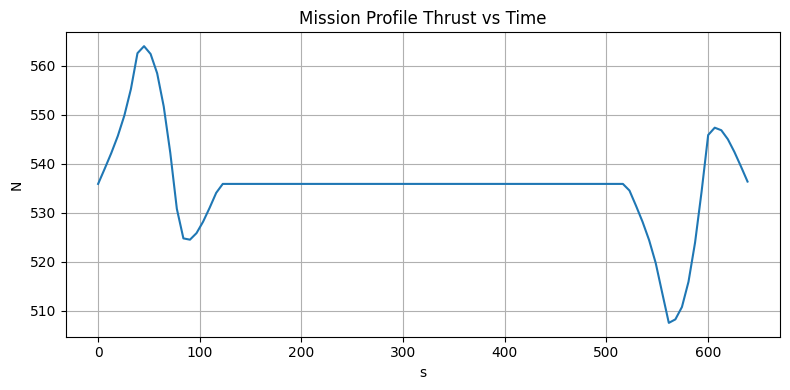

In [30]:
# force
plt.figure(figsize=(8, 4))
plt.title("Mission Profile Thrust vs Time")
t_range = np.linspace(0, opt.mission_profile.duration-1, 100)
force = np.zeros(len(t_range))
for i, t in enumerate(t_range):
    p,v,a = opt.mission_profile.time_solve(t)
    force[i] =  ((a[1] + opt.parameters["gravity"]) * opt.drone_mass) + (np.sign(v[1]) * (v[1] ** 2) * opt.drone_geometry.projected_surface_area * opt.parameters["air_density"] * opt.parameters["drag_coeff"])

plt.plot(t_range, force)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()



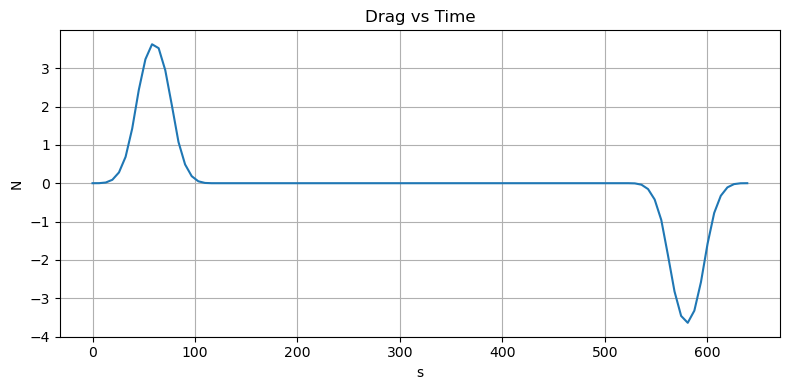

In [116]:




# Drag
plt.figure(figsize=(8, 4))
plt.title("Drag vs Time")
t_range = np.linspace(0, opt.mission_profile.duration-1, 100)
drag = np.zeros(len(t_range))
for i, t in enumerate(t_range):
    p,v,a = opt.mission_profile.time_solve(t)
    drag[i] = np.sign(v[1]) * (v[1] ** 2) * opt.drone_geometry.projected_surface_area * opt.parameters["air_density"] * opt.parameters["drag_coeff"] / 8

plt.plot(t_range, drag)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()


In [26]:

sys = opt.fea.beam_system
print("FEA Table")
print(dir(sys.beams[0]))
print("beam name,start node,max stress at start node (MPa),end node,max stress at end node (Mpa)")
for beam in sys.beams:
    print(f"{beam.name},{beam.start_node.name},{beam.bending_stresses_0},{beam.end_node.name},{beam.bending_stresses_1}")

FEA Table
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'a_inv_y_shape_vector', 'a_inv_y_shape_vector_dynamic_harmonic', 'a_inv_y_shape_vector_ts', 'a_inv_z_shape_vector', 'a_inv_z_shape_vector_dynamic_harmonic', 'a_inv_z_shape_vector_ts', 'applied_stiffness_matrix', 'beam_type', 'bending_strains_0', 'bending_strains_0_dynamic', 'bending_strains_0_ts', 'bending_strains_1', 'bending_strains_1_dynamic', 'bending_strains_1_ts', 'bending_stresses_0', 'bending_stresses_0_dynamic', 'bending_stresses_0_ts', 'bending_stresses_1', 'bending_stresses_1_dynamic', 'bending_stresses_1_ts', 'calc_failure_criterion_swt', 'd_local', 'd_local_dynamic_